Will plot evaluation data from trained models.

In [458]:
import os, sys, re, pickle
import matplotlib.pyplot as plt
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.utils.model_handling import get_models_evaluation_data, get_model_cfg
from src.utils.visualization import plot_training_metrics

In [459]:
project_root = os.path.abspath(os.path.join(os.getcwd(), '../'))
models = os.listdir(os.path.join(project_root, 'results', 'models'))

In [460]:
plot_path = os.path.join(project_root, 'results', 'plots', 'baseline_vs_expert')

# Expert Rewards

In [461]:
data_expert = {}
file_path = os.path.join(project_root, 'results', 'expert', 'evaluation-expert-reward_per_episode_all-env_setup-coef_of_var_0.pkl')
with open(file_path, 'rb') as f:
    expert_eval_data = pickle.load(f)

In [462]:
env_seed = []
data_expert = []

for env_info, eval_data in expert_eval_data.items():
    env_seed.append(int(re.findall(r'\d+', env_info)[0]))
    data_expert.append(int(np.sum(eval_data)))

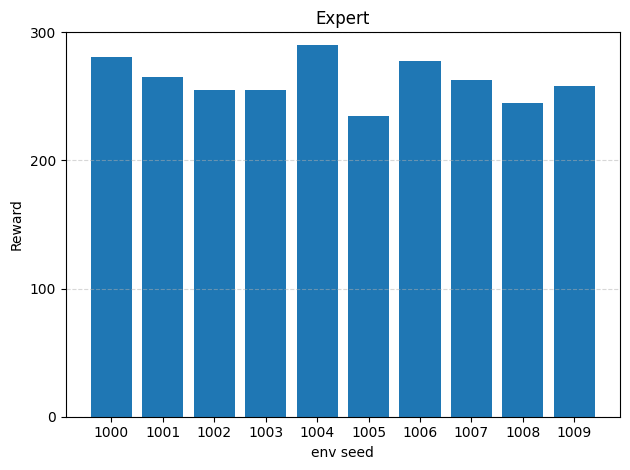

In [463]:
plt.bar(env_seed, data_expert)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.yticks([0, 100, 200, 300])
plt.xticks(env_seed)
plt.xlabel('env seed')
plt.ylabel('Reward')
plt.ylim(0, 300)
plt.title('Expert')
plt.tight_layout()

os.makedirs(plot_path, exist_ok=True)
plt.savefig(os.path.join(plot_path, 'expert_rewards.svg'))
plt.show()

In [464]:
print(
    f'''
    Expert
    mean: {np.mean(data_expert)},
    std: {np.std(data_expert)},
    sum: {np.sum(data_expert)},
    '''
)
expert_mean = np.mean(data_expert)
expert_std = np.std(data_expert)


    Expert
    mean: 262.5,
    std: 15.938946012832844,
    sum: 2625,
    


# Rewards per environment seed (per model)

Readind evaluation dictionary per model.

In [465]:
data = {}
for model_id in models:
    data[model_id] = {}

    # get evaluation .pkl as dict
    eval_data = get_models_evaluation_data(model_id=model_id, infer_seq_len=14)

    try:
        for env_info, eval_data in eval_data.items():
            env_seed = int(re.findall(r'\d+', env_info)[0])
            data[model_id][env_seed] = np.round(np.sum(eval_data), 2)
    except:
        pass

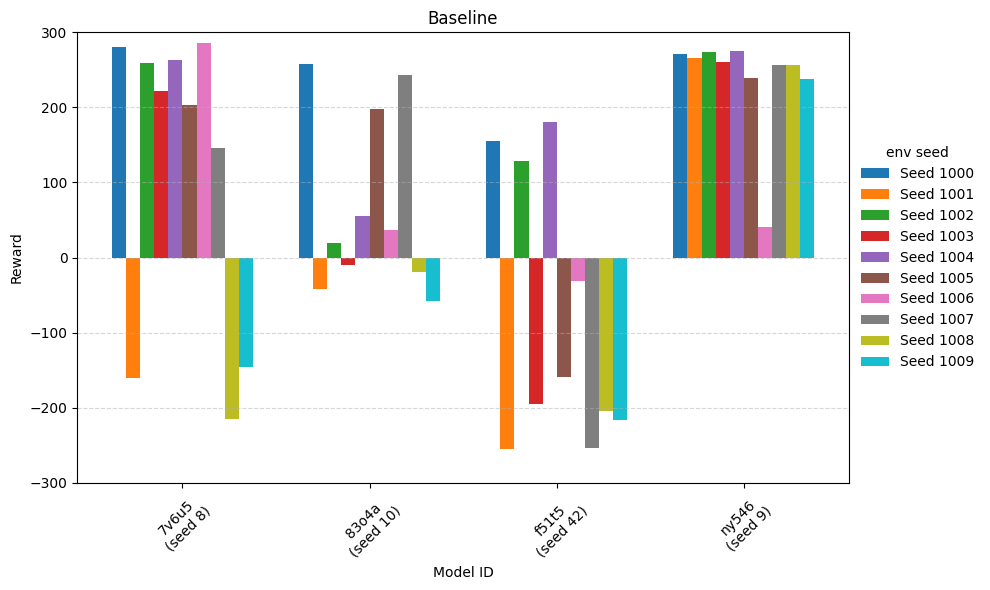

In [466]:
# Extract keys
models = list(data.keys())
env_seeds = sorted(next(iter(data.values())).keys())  # e.g. [1000, 1001, 1002, 1003, 1004]

# Group bar plot setup
x = np.arange(len(models))
bar_width = 0.075
colors = plt.cm.tab10(np.linspace(0, 1, len(env_seeds)))

plt.figure(figsize=(10, 6))

# Plot one bar per env seed
for i, seed in enumerate(env_seeds):
    rewards = [data[m][seed] for m in models]
    plt.bar(x + i * bar_width, rewards, width=bar_width, label=f"Seed {seed}", color=colors[i])

labels = []
for model_id in models:
    cfg = get_model_cfg(model_id=model_id)
    labels.append(f'{model_id}\n(seed {cfg.seed})')

# Formatting
plt.xticks(x + bar_width * (len(env_seeds) - 1) / 2, labels, rotation=45)
plt.xlabel("Model ID")
plt.ylabel("Reward")
plt.legend(title="env seed", loc='center left', bbox_to_anchor=(1.0, 0.5), framealpha=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(-300, 300)
plt.title('Baseline')
plt.tight_layout()

os.makedirs(plot_path, exist_ok=True)
plt.savefig(os.path.join(plot_path, 'baseline-v1_rewards.svg'))
plt.show()

In [467]:
for key, val in data.items():
    rewards = list(val.values())
    print(
        f'''
        {key}
        mean: {np.mean(rewards)},
        std: {np.std(rewards)},
        sum: {np.sum(rewards)},
        '''
    )


        7v6u5
        mean: 113.915,
        std: 192.93880010251956,
        sum: 1139.15,
        

        83o4a
        mean: 68.264,
        std: 113.45529447319768,
        sum: 682.64,
        

        f51t5
        mean: -85.31800000000001,
        std: 168.21760875722848,
        sum: -853.1800000000001,
        

        ny546
        mean: 237.714,
        std: 66.90604684182141,
        sum: 2377.14,
        


# Best model varying inference sequence length

In [468]:
mean_all = []
stds_all = []
infer_seq_lens = [4, 6, 8, 10, 12, 14, 16]

for model_id in models:
    mean = []
    std = []

    for seq_len in infer_seq_lens:

        eval_data = get_models_evaluation_data(model_id=model_id, infer_seq_len=seq_len)

        try:
            _ = []

            for env_info, eval_data in eval_data.items():
                _.append(np.round(np.sum(eval_data), 2))

            mean.append(np.mean(_))
            std.append(np.std(_))
        except:
            pass
    
    mean_all.append(mean)
    stds_all.append(std)

[np.float64(150.31900000000002), np.float64(125.894), np.float64(112.03399999999999), np.float64(153.502), np.float64(208.484), np.float64(113.915), np.float64(158.897)]
[np.float64(169.3927125616684), np.float64(205.0995449629277), np.float64(194.5949421336536), np.float64(182.28544559563716), np.float64(75.8750440131668), np.float64(192.93880010251956), np.float64(153.47824465050414)]
[np.float64(78.00399999999999), np.float64(264.94899999999996), np.float64(220.224), np.float64(244.321), np.float64(239.54500000000002), np.float64(237.714), np.float64(220.121)]
[np.float64(123.72881581911305), np.float64(16.15121014041982), np.float64(80.78386041778394), np.float64(64.41476328451421), np.float64(61.40262474031545), np.float64(66.90604684182141), np.float64(90.24015330771552)]


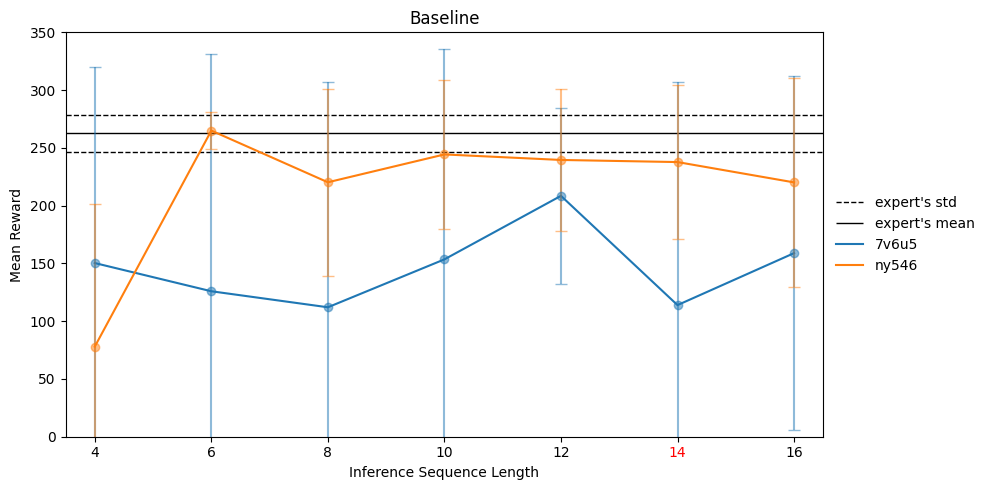

In [469]:
fig = plt.figure(figsize=(10, 5))

plt.xlabel('Inference Sequence Length')
plt.ylabel('Mean Reward')

plt.hlines(expert_mean-expert_std, 3.5, 16.5, lw=1, ls='--', color='k', label="expert's std")
plt.hlines(expert_mean, 3.5, 16.5, lw=1, label="expert's mean", color='k')
plt.hlines(expert_mean+expert_std, 3.5, 16.5, lw=1, ls='--', color='k')

for i, _ in enumerate(mean_all):
    if len(mean_all[i]) == len(infer_seq_lens):
        line, = plt.plot(infer_seq_lens, mean_all[i], ls='-', label=models[i])
        print(mean_all[i])
        print(stds_all[i])
        plt.errorbar(infer_seq_lens, mean_all[i], yerr=stds_all[i], capsize=4, fmt="o", ecolor=line.get_color(), color=line.get_color(), alpha=0.5)

plt.ylim(0, 350)
plt.xlim(3.5, 16.5)
plt.title('Baseline')

plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), framealpha=0)

ax = plt.gca()  # get current axes

xticks = ax.get_xticklabels()
xticks[6].set_color('red')   # change 4th tick label

plt.tight_layout()
plt.savefig(os.path.join(plot_path, 'baseline-v1_infer_seq_len.svg'))
plt.show()